In [2]:
print("Welcome to Rising Waters Project")

Welcome to Rising Waters Project


# Rising Waters: A Machine Learning Approach to Flood Prediction

## Project Description

This project predicts the likelihood of floods using Machine Learning algorithms based on historical weather data. The models include Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and XGBoost. The best-performing model is integrated into a Flask web application to provide flood predictions.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

## Reading the Dataset

In [26]:
import os
print(os.getcwd())

C:\Users\Welcome\Rising-Waters-Flood-Prediction\notebooks


In [27]:
import pandas as pd

dataset = pd.read_excel("../dataset/flood.xlsx")

In [28]:
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [29]:
dataset.shape

(115, 11)

In [30]:
dataset.columns

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='object')

In [31]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


## Descriptive Analysis

In [32]:
dataset.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


## Handling Missing Values

In [33]:
dataset.isnull().sum()

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

In [34]:
dataset.duplicated().sum()

np.int64(0)

In [35]:
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


# Univariate Analysis

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

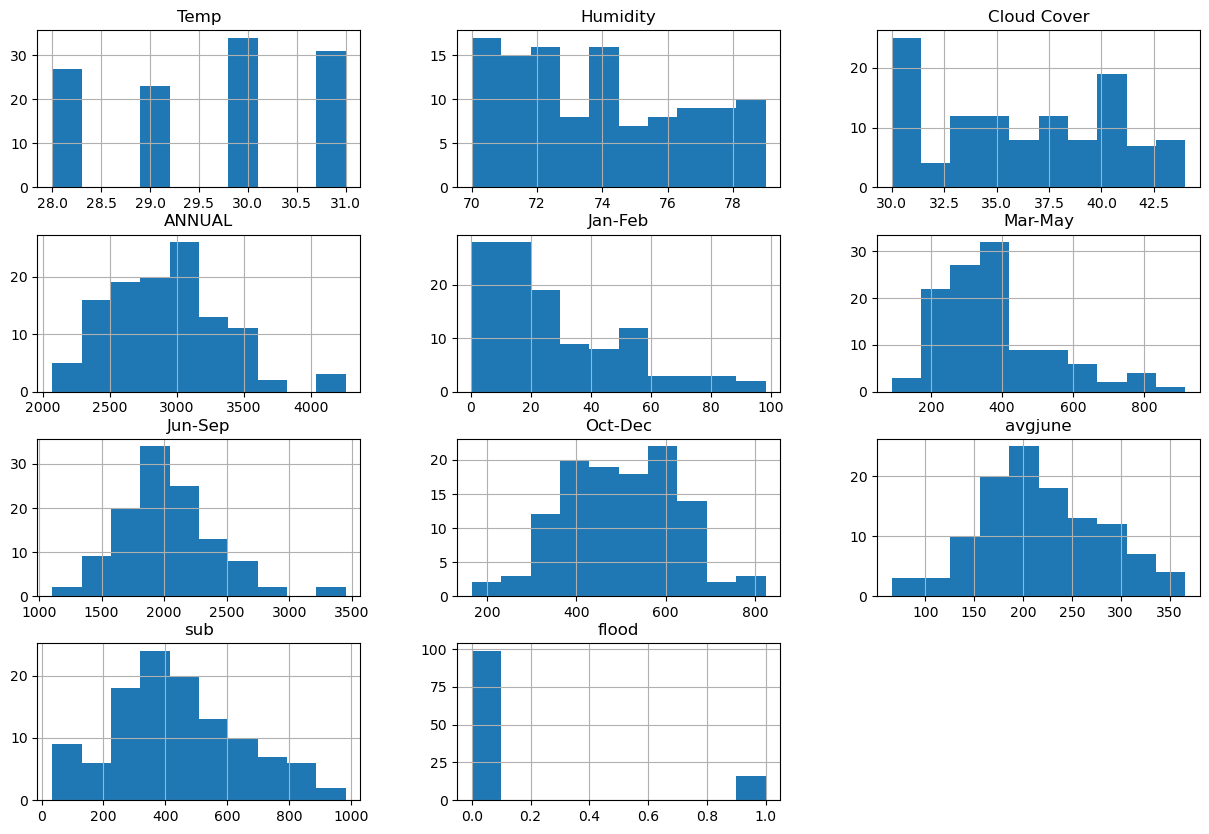

In [37]:
dataset.hist(figsize=(15,10))
plt.show()

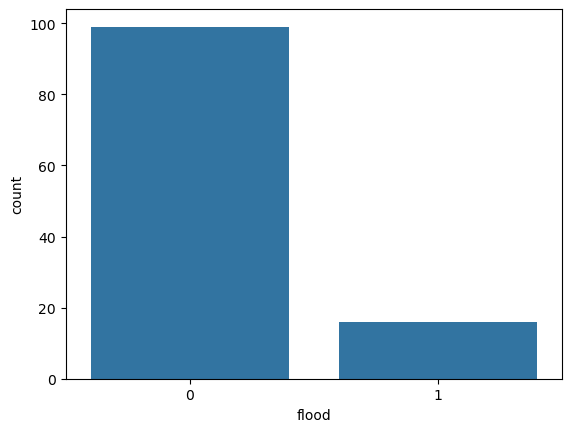

In [40]:
sns.countplot(x='flood', data=dataset)
plt.show()

# Multivariate Analysis

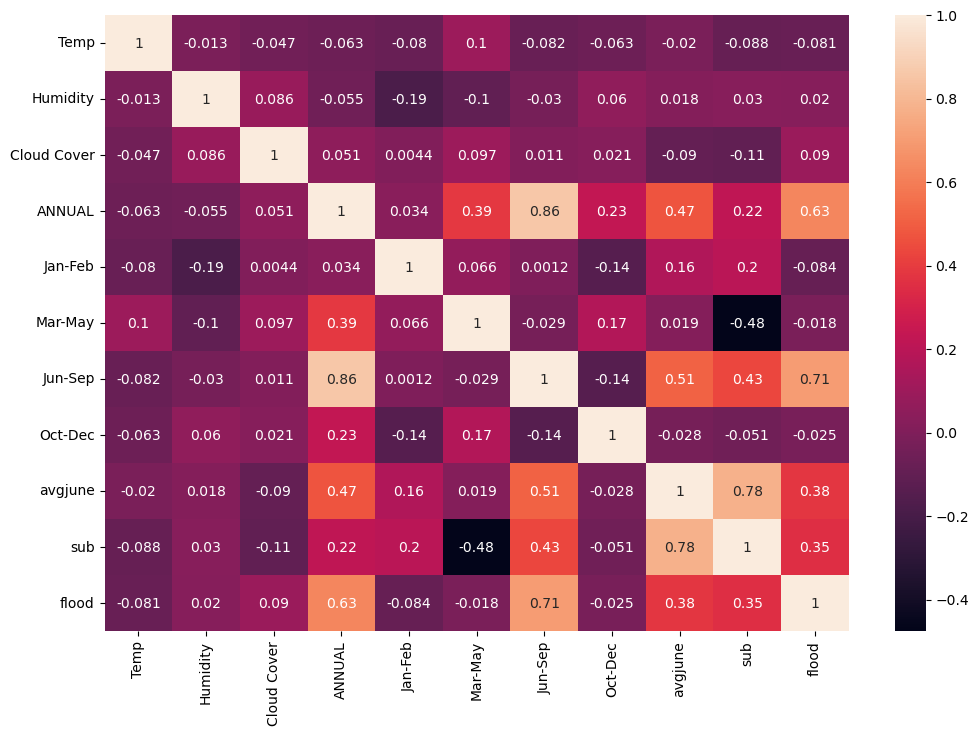

In [41]:
plt.figure(figsize=(12,8))
sns.heatmap(dataset.corr(), annot=True)
plt.show()

# Descriptive Analysis

In [42]:
dataset.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


# Handling Missing Values

In [43]:
dataset.isnull().sum()

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

# Handling Outliers

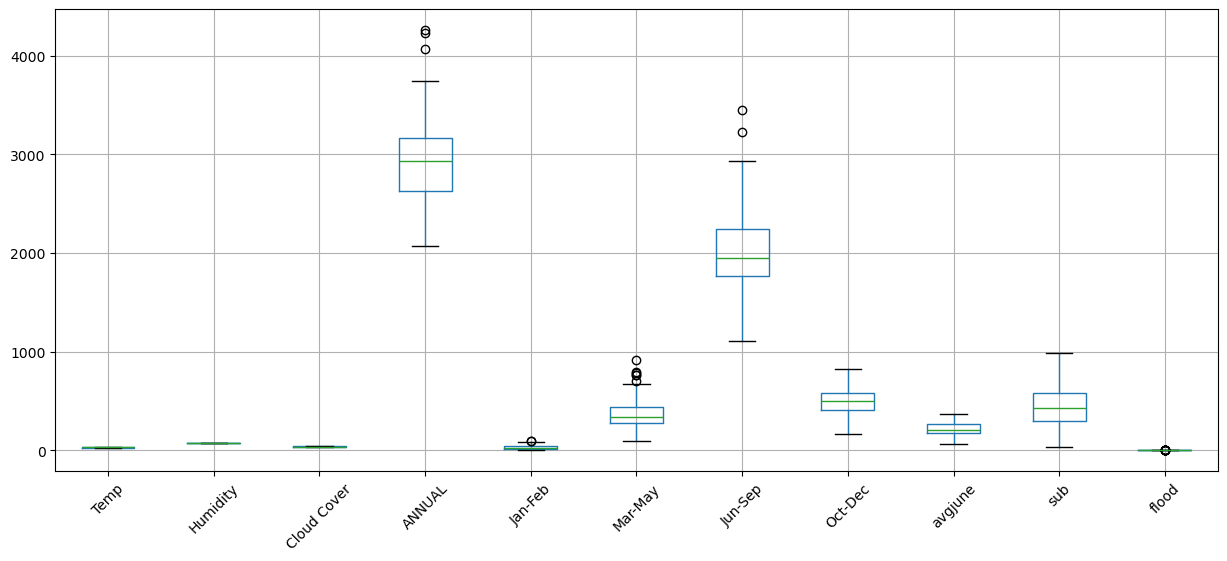

In [44]:
plt.figure(figsize=(15,6))
dataset.boxplot()
plt.xticks(rotation=45)
plt.show()

# Handling Categorical Values

In [45]:
dataset.dtypes

Temp             int64
Humidity         int64
Cloud Cover      int64
ANNUAL         float64
Jan-Feb        float64
Mar-May        float64
Jun-Sep        float64
Oct-Dec        float64
avgjune        float64
sub            float64
flood            int64
dtype: object

# Splitting Data into Training and Test Sets

In [55]:
X = dataset.drop('flood', axis=1)
y = dataset['flood']

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [59]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (92, 10)
Testing Data Shape: (23, 10)


# Feature Scaling

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [62]:
print(X_train[:5])

[[-0.61039689 -0.66344859  0.15886699  1.08604492 -0.35983282  2.57623804
  -0.53467443  2.2628558  -1.6046566  -0.59664114]
 [-0.61039689  0.67069939 -0.8320322   1.06253895  0.45537729 -0.39714984
   1.68429033 -1.35274855  0.32161235  0.87878852]
 [ 1.23080028  0.67069939 -0.3365826   1.10384556  1.0579239  -0.38839723
   1.15383728  0.36324965  1.12702475  1.35588824]
 [ 0.3102017   1.33777339 -0.3365826   0.46713037 -0.35097184 -0.09455949
  -0.21844281  2.46118335  0.16497428  0.24379968]
 [-1.53099547 -1.33052258 -1.57520658  1.27249521 -0.09843392 -1.08610557
   2.21134304 -1.37134176  0.46307442  1.05580085]]


# Decision Tree Model

In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [64]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [66]:
dt_prediction = dt_model.predict(X_test)

In [67]:
dt_accuracy = accuracy_score(y_test, dt_prediction)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


# Random Forest Model

In [68]:
from sklearn.ensemble import RandomForestClassifier

In [69]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
rf_prediction = rf_model.predict(X_test)

In [71]:
rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


# K-Nearest Neighbours Model

In [72]:
from sklearn.neighbors import KNeighborsClassifier

In [73]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [74]:
knn_prediction = knn_model.predict(X_test)

In [75]:
knn_accuracy = accuracy_score(
    y_test,
    knn_prediction
)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9130434782608695


# XGBoost Model

In [77]:
from xgboost import XGBClassifier

In [78]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [79]:
xgb_prediction = xgb_model.predict(X_test)

In [80]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_prediction
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 1.0


# Comparing the Models

In [81]:
print("Decision Tree :", dt_accuracy)
print("Random Forest :", rf_accuracy)
print("KNN :", knn_accuracy)
print("XGBoost :", xgb_accuracy)

Decision Tree : 1.0
Random Forest : 1.0
KNN : 0.9130434782608695
XGBoost : 1.0


# Evaluating Performance

In [82]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [83]:
print(confusion_matrix(
    y_test,
    xgb_prediction
))

[[20  0]
 [ 0  3]]


In [84]:
print(classification_report(
    y_test,
    xgb_prediction
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



import joblib

In [88]:
import joblib

joblib.dump(xgb_model, "../model/floods.save")
joblib.dump(scaler, "../model/scaler.save")

['../model/scaler.save']

# Verifying the Model

In [86]:
import os

os.listdir("../model")

['floods.save', 'README.md']

In [89]:
print(dataset.columns.tolist())

['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood']


In [90]:
import os

print(os.listdir("../model"))

['floods.save', 'README.md', 'scaler.save']


In [91]:
sample = X_test[0].reshape(1, -1)

prediction = xgb_model.predict(sample)

print(prediction)

[0]


In [92]:
print(dataset["flood"].unique())

[0 1]


In [93]:
print(X.columns.tolist())

['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub']


# Conclusion

In this project, multiple Machine Learning classification algorithms were trained and evaluated for flood prediction using weather and rainfall data. Among the tested models, XGBoost achieved the highest accuracy and was selected as the final model. The trained model and scaler were saved and integrated into a Flask web application to provide real-time flood risk predictions. This system can help authorities issue early warnings and support disaster management decisions.

In [95]:
for i in range(len(X_test)):
    pred = xgb_model.predict(X_test[i].reshape(1,-1))
    if pred[0] == 1:
        print("Row:", i)
        print(X_test[i])
        break

Row: 5
[-1.53099547 -0.66344859  1.39749097  1.45689159 -0.89592208 -0.28023993
  1.13610694  1.82591539  1.52810495  2.00460657]


In [96]:
flood_rows = dataset[dataset["flood"] == 1]
print(flood_rows.head())

    Temp  Humidity  Cloud Cover  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  \
1     28        75           40  3326.6      9.3    275.7   2403.4    638.2   
6     29        74           40  3671.1     23.7    328.0   2737.8    581.7   
11    28        77           40  3451.3     16.9    351.1   2453.1    630.2   
22    28        70           30  3484.7     25.3    202.3   2928.4    328.6   
23    30        71           41  4226.4     22.2    363.0   3451.3    389.9   

       avgjune    sub  flood  
1   130.300000  256.4      1  
6   256.966667  669.5      1  
11  316.066667  730.9      1  
22  240.833333  642.5      1  
23  337.233333  826.3      1  
